# 30. Ensemble Alpha Model (Production Grade)

## Objective
Enhance Step-28 with controlled ensemble improvements while preserving rank structure and avoiding signal destruction.

**Design principles used here:**
- Step-28 structure retained as base
- no residual target replacement
- no synthetic sector clustering
- no aggressive feature filtering
- strict time-series integrity and per-date cross-sectional operations only

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple
import json
import logging

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor

try:
    from lightgbm import LGBMRegressor
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 420)
pd.set_option('display.width', 240)

TRAIN_START = pd.Timestamp('2023-01-01')
TRAIN_END = pd.Timestamp('2024-12-31')
TEST_START = pd.Timestamp('2025-01-01')
TEST_END = pd.Timestamp('2025-12-31')

VAL_START = pd.Timestamp('2024-07-01')
VAL_END = TRAIN_END

TOP_N = 10
ANNUALIZATION_DAYS = 252
RANDOM_STATE = 42
SEQ_LEN = 15
LSTM_EPOCHS = 6
LSTM_BATCH_SIZE = 128
LSTM_HIDDEN = 32

logger = logging.getLogger('ensemble_alpha_model')
if not logger.handlers:
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))
    logger.addHandler(h)
logger.setLevel(logging.INFO)

if not HAS_LIGHTGBM:
    logger.info('LightGBM is unavailable; ensemble will use XGBoost + LSTM (if available).')
if not HAS_TORCH:
    logger.info('PyTorch is unavailable; LSTM integration will be skipped.')
if not HAS_SHAP:
    logger.info('SHAP is unavailable; SHAP section will be skipped.')

if HAS_TORCH:
    torch.manual_seed(RANDOM_STATE)
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using torch device: {DEVICE}')


[INFO] SHAP is unavailable; SHAP section will be skipped.


Using torch device: cpu


In [2]:
def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'ml_pipeline').exists() and (c / 'CLAUDE.md').exists():
            return c
    raise FileNotFoundError('Unable to locate project root.')


def cs_zscore(s: pd.Series) -> pd.Series:
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(0.0, index=s.index)
    return (s - s.mean()) / sd


def sharpe_ratio(daily_returns: pd.Series, annualization: int = ANNUALIZATION_DAYS) -> float:
    mu = float(daily_returns.mean())
    sigma = float(daily_returns.std(ddof=1))
    if sigma == 0.0 or np.isnan(sigma):
        return np.nan
    return (mu / sigma) * np.sqrt(annualization)


def max_drawdown(equity: pd.Series) -> float:
    running_max = equity.cummax()
    dd = equity / running_max - 1.0
    return float(dd.min()) if len(dd) else np.nan


def compute_daily_ic(df_in: pd.DataFrame, pred_col: str, target_col: str = 'target_future_return_t3') -> pd.DataFrame:
    rows = []
    for dt, g in df_in.groupby('Date', sort=True):
        g = g[[pred_col, target_col]].dropna()
        if len(g) < 20:
            continue
        corr, _ = spearmanr(g[pred_col], g[target_col])
        if pd.notna(corr):
            rows.append({'Date': dt, 'IC': float(corr)})
    out = pd.DataFrame(rows)
    if len(out):
        out['IC_rolling_20'] = out['IC'].rolling(20, min_periods=5).mean()
    return out


def long_short_top_bottom(df_in: pd.DataFrame, score_col: str, ret_col: str, top_n: int = TOP_N) -> Tuple[pd.DataFrame, pd.Series]:
    picks_all = []
    for dt, g in df_in.groupby('Date', sort=True):
        if len(g) < 2 * top_n:
            continue
        g = g.sort_values(score_col, ascending=False).copy()
        long_leg = g.head(top_n).copy()
        short_leg = g.tail(top_n).copy()
        long_leg['side'] = 1
        short_leg['side'] = -1
        picks = pd.concat([long_leg, short_leg], ignore_index=True)
        picks['weight'] = picks['side'] * (1.0 / top_n)
        picks['pnl_component'] = picks['weight'] * picks[ret_col]
        picks_all.append(picks)
    assert len(picks_all) > 0, 'No portfolios formed.'
    trade_df = pd.concat(picks_all, ignore_index=True)
    daily = trade_df.groupby('Date', as_index=True)['pnl_component'].sum().sort_index()
    return trade_df, daily


def rolling_skew(x: pd.Series, window: int = 20, min_periods: int = 10) -> pd.Series:
    return x.rolling(window, min_periods=min_periods).skew()


def rolling_autocorr_lag1(x: pd.Series, window: int = 5, min_periods: int = 5) -> pd.Series:
    def _f(v: np.ndarray) -> float:
        s = pd.Series(v)
        return float(s.autocorr(lag=1)) if s.std(ddof=0) > 0 else np.nan
    return x.rolling(window, min_periods=min_periods).apply(_f, raw=True)


ROOT = resolve_project_root()
BASE = ROOT / 'ml_pipeline'
RAW_PATH_A = BASE / 'Market_Data' / 'processed' / 'final_model_dataset.parquet'
RAW_PATH_B = BASE / 'Market_Data' / 'processed' / 'final_model_dataset_with_volatility.parquet'
STEP28_PATH = BASE / 'Market_Data' / 'final' / 'cross_sectional_alpha_results.parquet'
OUT_PATH = BASE / 'Market_Data' / 'final' / 'ensemble_alpha_results.parquet'

RAW_PATH = RAW_PATH_A if RAW_PATH_A.exists() else RAW_PATH_B
assert RAW_PATH.exists(), f'Missing source dataset: {RAW_PATH}'
assert STEP28_PATH.exists(), f'Missing Step-28 benchmark file: {STEP28_PATH}'

raw = pd.read_parquet(RAW_PATH).copy()
raw['Date'] = pd.to_datetime(raw['Date'])
raw['Ticker'] = raw['Ticker'].astype(str)
raw = raw.sort_values(['Ticker', 'Date']).reset_index(drop=True)

g_close = raw.groupby('Ticker', sort=False)['Close']
if 'Return' not in raw.columns:
    raw['Return'] = g_close.pct_change(1)
g_ret = raw.groupby('Ticker', sort=False)['Return']
g_vol = raw.groupby('Ticker', sort=False)['Volume']

# Target (unchanged Step-28 structure): future return t+3.
raw['target_future_return_t3'] = g_close.shift(-3) / raw['Close'] - 1.0

# Controlled feature enhancement (3-5 features only).
if 'momentum_5' not in raw.columns:
    raw['momentum_5'] = g_close.pct_change(5)
raw['volume_spike'] = raw['Volume'] / g_vol.transform(lambda x: x.rolling(20, min_periods=10).mean())
raw['momentum_vol_ratio'] = raw['momentum_5'] / (raw['Volatility_20'] + 1e-6)
raw['volume_momentum_interaction'] = raw['volume_spike'] * raw['momentum_5']
raw['rolling_skew_20'] = raw.groupby('Ticker', sort=False)['Return'].transform(lambda x: rolling_skew(x, 20, 10))
raw['return_autocorr_5'] = raw.groupby('Ticker', sort=False)['Return'].transform(lambda x: rolling_autocorr_lag1(x, 5, 5))

# Base Step-28-like features + new controlled features (no aggressive filtering).
base_features = [
    'Open', 'High', 'Low', 'Close', 'Volume', 'Return',
    'RSI', 'ROC', 'EMA_20', 'SMA_20', 'MACD', 'MACD_Signal',
    'ATR', 'Volatility_20', 'Volatility_50', 'Volume_MA_20',
    'SP500_RET', 'DOW_RET', 'GOLD_RET', 'OIL_RET', 'USDINR_RET', 'VIX_RET', 'NIFTY_RET',
    'Event_Count', 'Avg_Tone', 'War_Flag', 'Crisis_Flag', 'Inflation_Flag', 'Rate_Hike_Flag',
    'return_roll_mean_5', 'return_roll_std_5', 'momentum_5',
    'return_roll_mean_10', 'return_roll_std_10', 'momentum_10',
    'return_roll_mean_20', 'return_roll_std_20', 'momentum_20',
]
new_features = ['momentum_vol_ratio', 'volume_momentum_interaction', 'rolling_skew_20', 'return_autocorr_5', 'volume_spike']
all_features = [c for c in (base_features + new_features) if c in raw.columns]

# Cross-sectional normalization per date (z + rank) using contemporaneous values only.
for f in all_features:
    raw[f'{f}_cs_z'] = raw.groupby('Date')[f].transform(cs_zscore)
    raw[f'{f}_cs_rank'] = raw.groupby('Date')[f].rank(pct=True)

model_features = [f'{f}_cs_z' for f in all_features] + [f'{f}_cs_rank' for f in all_features]

df = raw[['Date', 'Ticker', 'target_future_return_t3', 'Volatility_20'] + model_features].copy()
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=['target_future_return_t3'] + model_features).copy()

train_mask = (df['Date'] >= TRAIN_START) & (df['Date'] <= TRAIN_END)
test_mask = (df['Date'] >= TEST_START) & (df['Date'] <= TEST_END)
val_mask = (df['Date'] >= VAL_START) & (df['Date'] <= VAL_END)
subtrain_mask = train_mask & (~val_mask)

assert train_mask.any() and test_mask.any(), 'Train/Test split is empty.'

X_train = df.loc[train_mask, model_features]
X_test = df.loc[test_mask, model_features]
y_train = df.loc[train_mask, 'target_future_return_t3'].to_numpy(dtype=float)

X_subtrain = df.loc[subtrain_mask, model_features]
y_subtrain = df.loc[subtrain_mask, 'target_future_return_t3'].to_numpy(dtype=float)
X_val = df.loc[val_mask, model_features]
y_val = df.loc[val_mask, 'target_future_return_t3'].to_numpy(dtype=float)

logger.info('Rows | train=%s test=%s', f'{int(train_mask.sum()):,}', f'{int(test_mask.sum()):,}')
display(df[['Ticker', 'Date', 'target_future_return_t3']].head(10))


[INFO] Rows | train=38,869 test=23,520


,Ticker,Date,target_future_return_t3
9,ABB,2023-05-02,0.080386
10,ABB,2023-05-03,0.101054
11,ABB,2023-05-04,0.044358
12,ABB,2023-05-05,0.025976
13,ABB,2023-05-08,0.015213
14,ABB,2023-05-09,0.035592
15,ABB,2023-05-10,0.010484
16,ABB,2023-05-11,0.012965
17,ABB,2023-05-12,-0.005999
18,ABB,2023-05-15,0.010907


In [3]:
# STEP 1: Base model reconstruction (LGBM + XGB)
pred_test: Dict[str, np.ndarray] = {}
val_pred: Dict[str, np.ndarray] = {}

xgb = XGBRegressor(
    n_estimators=700,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=2.0,
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb.fit(X_subtrain if len(X_subtrain) else X_train, y_subtrain if len(X_subtrain) else y_train)
val_pred['xgb'] = xgb.predict(X_val) if len(X_val) else np.array([])

xgb_full = XGBRegressor(
    n_estimators=700,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=2.0,
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_full.fit(X_train, y_train)
pred_test['xgb'] = xgb_full.predict(X_test)

if HAS_LIGHTGBM:
    lgb = LGBMRegressor(
        objective='regression',
        n_estimators=700,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_STATE,
    )
    lgb.fit(X_subtrain if len(X_subtrain) else X_train, y_subtrain if len(X_subtrain) else y_train)
    val_pred['lgb'] = lgb.predict(X_val) if len(X_val) else np.array([])

    lgb_full = LGBMRegressor(
        objective='regression',
        n_estimators=700,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_STATE,
    )
    lgb_full.fit(X_train, y_train)
    pred_test['lgb'] = lgb_full.predict(X_test)
else:
    pred_test['lgb'] = pred_test['xgb'].copy()

# STEP 3: Core weighted ensemble (0.6 LGBM + 0.4 XGB)
pred_test['ensemble_basic'] = 0.6 * pred_test['lgb'] + 0.4 * pred_test['xgb']

# BONUS: IC-based model weights on validation set (if possible)
if len(X_val):
    val_df = df.loc[val_mask, ['Date', 'Ticker', 'target_future_return_t3']].copy()
    if 'lgb' in val_pred:
        val_df['pred_lgb'] = val_pred['lgb']
    else:
        val_df['pred_lgb'] = val_pred['xgb']
    val_df['pred_xgb'] = val_pred['xgb']

    ic_lgb_df = compute_daily_ic(val_df, 'pred_lgb')
    ic_xgb_df = compute_daily_ic(val_df, 'pred_xgb')
    ic_lgb = float(ic_lgb_df['IC'].mean()) if len(ic_lgb_df) else 0.0
    ic_xgb = float(ic_xgb_df['IC'].mean()) if len(ic_xgb_df) else 0.0

    ic_lgb_pos = max(ic_lgb, 1e-6)
    ic_xgb_pos = max(ic_xgb, 1e-6)
    w_lgb_dyn = ic_lgb_pos / (ic_lgb_pos + ic_xgb_pos)
    w_xgb_dyn = ic_xgb_pos / (ic_lgb_pos + ic_xgb_pos)
else:
    w_lgb_dyn, w_xgb_dyn = 0.6, 0.4

# STEP 4: Optional deep model integration (LSTM)
pred_test['lstm'] = np.zeros_like(pred_test['xgb'])
lstm_available = False

if HAS_TORCH:
    class LSTMRegressor(nn.Module):
        def __init__(self, n_features: int, hidden: int = LSTM_HIDDEN) -> None:
            super().__init__()
            self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden, num_layers=1, batch_first=True)
            self.head = nn.Linear(hidden, 1)

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            out, _ = self.lstm(x)
            h = out[:, -1, :]
            return self.head(h).squeeze(-1)

    seq_feats = [c for c in model_features if c.endswith('_cs_z')]
    seq_source = df[['Ticker', 'Date', 'target_future_return_t3'] + seq_feats].copy().sort_values(['Ticker', 'Date'])

    scaler = StandardScaler()
    scaler.fit(seq_source.loc[(seq_source['Date'] >= TRAIN_START) & (seq_source['Date'] <= TRAIN_END), seq_feats].fillna(0.0))
    seq_source[seq_feats] = scaler.transform(seq_source[seq_feats].fillna(0.0))

    X_seq_tr, y_seq_tr, X_seq_te, idx_seq_te = [], [], [], []
    for _, g in seq_source.groupby('Ticker', sort=False):
        g = g.reset_index()
        vals = g[seq_feats].to_numpy(dtype=np.float32)
        tgt = g['target_future_return_t3'].to_numpy(dtype=np.float32)
        dts = g['Date'].to_numpy()
        original_idx = g['index'].to_numpy()

        for i in range(SEQ_LEN - 1, len(g)):
            if np.isnan(tgt[i]):
                continue
            seq = vals[i - SEQ_LEN + 1:i + 1]
            if np.isnan(seq).any():
                continue
            if TRAIN_START <= pd.Timestamp(dts[i]) <= TRAIN_END:
                X_seq_tr.append(seq)
                y_seq_tr.append(tgt[i])
            elif TEST_START <= pd.Timestamp(dts[i]) <= TEST_END:
                X_seq_te.append(seq)
                idx_seq_te.append(int(original_idx[i]))

    if len(X_seq_tr) > 1000 and len(X_seq_te) > 0:
        Xtr = torch.from_numpy(np.asarray(X_seq_tr, dtype=np.float32))
        ytr = torch.from_numpy(np.asarray(y_seq_tr, dtype=np.float32))
        train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=LSTM_BATCH_SIZE, shuffle=False)

        model_lstm = LSTMRegressor(n_features=len(seq_feats)).to(DEVICE)
        opt = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)
        loss_fn = nn.MSELoss()

        model_lstm.train()
        for _ in range(LSTM_EPOCHS):
            for xb, yb in train_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                pred = model_lstm(xb)
                loss = loss_fn(pred, yb)
                opt.zero_grad()
                loss.backward()
                opt.step()

        Xte = torch.from_numpy(np.asarray(X_seq_te, dtype=np.float32)).to(DEVICE)
        model_lstm.eval()
        with torch.no_grad():
            pred_lstm_seq = model_lstm(Xte).cpu().numpy()

        lstm_map = pd.Series(pred_lstm_seq, index=idx_seq_te)
        test_index = df.loc[test_mask].index
        pred_test['lstm'] = pd.Series(index=test_index, dtype=float).map(lstm_map).fillna(0.0).to_numpy()
        lstm_available = True

# Final ensemble composition.
if lstm_available:
    # Keep 20% LSTM, split remaining 80% between LGB/XGB by validation IC.
    w_lgb = 0.8 * w_lgb_dyn
    w_xgb = 0.8 * w_xgb_dyn
    w_lstm = 0.2
else:
    w_lgb = w_lgb_dyn
    w_xgb = w_xgb_dyn
    w_lstm = 0.0

pred_test['final'] = w_lgb * pred_test['lgb'] + w_xgb * pred_test['xgb'] + w_lstm * pred_test['lstm']

# STEP 5: Temporal smoothing
test_frame = df.loc[test_mask, ['Date', 'Ticker', 'target_future_return_t3', 'Volatility_20']].copy()
for k, v in pred_test.items():
    test_frame[f'pred_{k}'] = v

test_frame = test_frame.sort_values(['Ticker', 'Date']).copy()
test_frame['pred_smoothed'] = test_frame.groupby('Ticker', sort=False)['pred_final'].transform(lambda x: x.rolling(3, min_periods=1).mean())

# STEP 6: Cross-sectional ranking
test_frame['pred_rank_pct'] = test_frame.groupby('Date')['pred_smoothed'].rank(pct=True)
test_frame['pred_zscore'] = test_frame.groupby('Date')['pred_smoothed'].transform(cs_zscore)

model_weights = {'weight_lgb': float(w_lgb), 'weight_xgb': float(w_xgb), 'weight_lstm': float(w_lstm)}
print('Model weights used:', model_weights)
display(test_frame.head(10))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019590 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14747
[LightGBM] [Info] Number of data points in the train set: 26843, number of used features: 81
[LightGBM] [Info] Start training from score 0.006295
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020279 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15157
[LightGBM] [Info] Number of data points in the train set: 38869, number of used features: 81
[LightGBM] [Info] Start training from score 0.004299
Model weights used: {'weight_lgb': 0.4, 'weight_xgb': 0.4, 'weight_lstm': 0.2}


,Date,Ticker,target_future_return_t3,Volatility_20,pred_xgb,pred_lgb,pred_ensemble_basic,pred_lstm,pred_final,pred_smoothed,pred_rank_pct,pred_zscore
421,2025-01-01,ABB,-0.044476,0.021760,-0.005145,-0.008881,-0.007387,0.0,-0.005611,-0.005611,0.114583,-0.711866
422,2025-01-02,ABB,-0.026916,0.021203,-0.007039,-0.013644,-0.011002,0.0,-0.008273,-0.006942,0.270833,-0.565717
423,2025-01-03,ABB,-0.021051,0.020883,-0.001624,-0.000277,-0.000816,0.0,-0.000760,-0.004881,0.239583,-0.585909
424,2025-01-06,ABB,-0.020822,0.021187,-0.008952,-0.017964,-0.014359,0.0,-0.010767,-0.006600,0.312500,-0.464707
425,2025-01-07,ABB,-0.043326,0.021548,-0.006599,-0.014810,-0.011525,0.0,-0.008563,-0.006697,0.197917,-0.587163
426,2025-01-08,ABB,-0.082282,0.020909,-0.002361,0.002626,0.000631,0.0,0.000106,-0.006408,0.187500,-0.519032
427,2025-01-09,ABB,-0.051809,0.021144,0.000449,0.013152,0.008071,0.0,0.005441,-0.001006,0.260417,-0.350931
428,2025-01-10,ABB,-0.034587,0.021147,0.003933,0.009016,0.006983,0.0,0.005180,0.003576,0.395833,-0.182246
429,2025-01-13,ABB,0.032574,0.022562,-0.002191,-0.004909,-0.003822,0.0,-0.002840,0.002593,0.541667,0.026475
430,2025-01-14,ABB,0.061969,0.021390,0.014329,0.021311,0.018519,0.0,0.014256,0.005532,0.770833,0.619506


,Mean_IC,IC_Std,IC_Hit_Rate
0,0.0001,0.145,0.4898


,Regime,Mean_IC,IC_Std,IC_Hit_Rate
0,LOW,-0.0186,0.1612,0.4348
1,MEDIUM,0.0221,0.1983,0.5289
2,HIGH,-0.0347,0.1941,0.4554


,decile,target_future_return_t3
0,1,0.00135
1,2,0.00168
2,3,0.00123
3,4,0.00178
4,5,0.00092
5,6,0.00110
6,7,0.00165
7,8,0.00101
8,9,0.00094
9,10,0.00134


Decile monotonicity Spearman: -0.4303


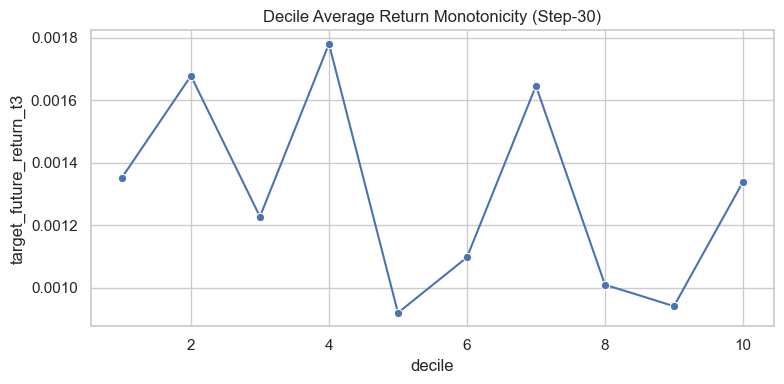

,Metric,Step-28,Step-30
0,Mean IC,0.0183,0.0001
1,IC std,0.1396,0.1450
2,Sharpe,2.6280,0.0645
3,Drawdown,-0.1300,-0.2663


Quality gate pass (IC >= Step-28, Sharpe >= Step-28, monotonicity positive): False


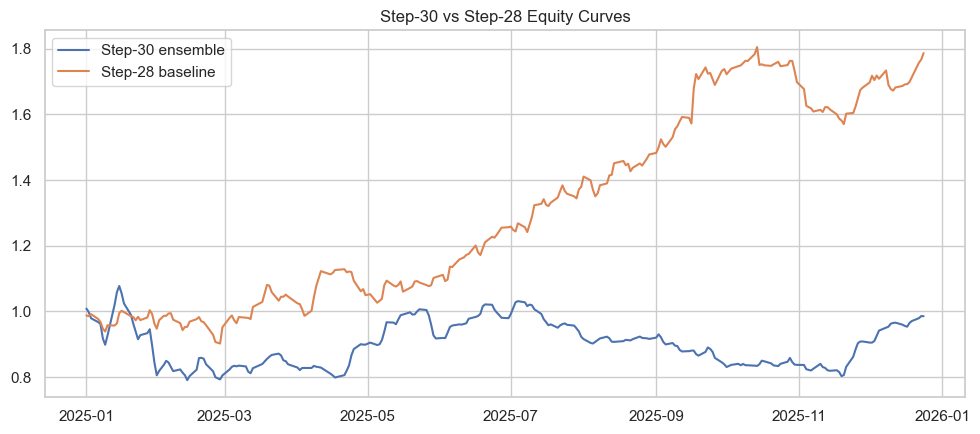

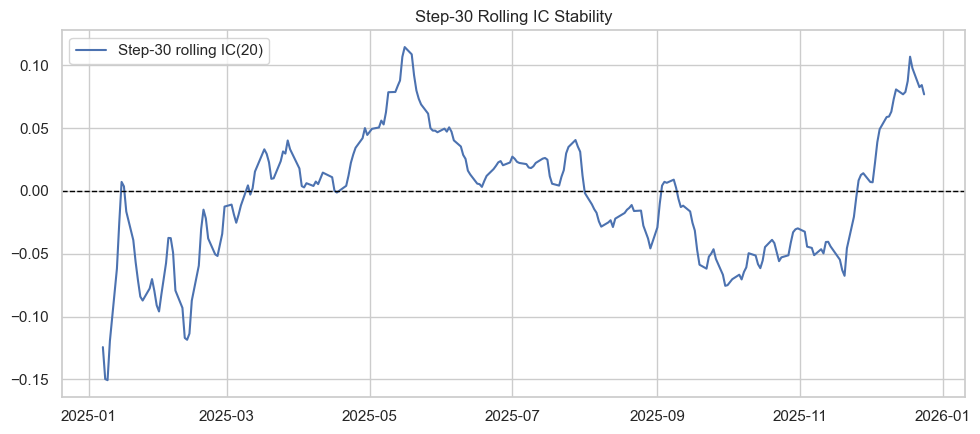

In [4]:
# STEP 7: IC evaluation
ic_daily = compute_daily_ic(test_frame, 'pred_smoothed', 'target_future_return_t3')
mean_ic = float(ic_daily['IC'].mean()) if len(ic_daily) else np.nan
std_ic = float(ic_daily['IC'].std(ddof=1)) if len(ic_daily) > 1 else np.nan
hit_ic = float((ic_daily['IC'] > 0).mean()) if len(ic_daily) else np.nan

# IC by regime
if 'volatility_regime_label' in raw.columns:
    regime_map = raw[['Date', 'Ticker', 'volatility_regime_label']].copy()
    regime_map['Regime'] = regime_map['volatility_regime_label'].astype(str).str.upper().replace({'STABLE': 'MEDIUM', 'NON-VOLATILE': 'LOW', 'NON_VOLATILE': 'LOW'})
    test_frame = test_frame.merge(regime_map[['Date', 'Ticker', 'Regime']], on=['Date', 'Ticker'], how='left')
else:
    q1 = float(raw.loc[(raw['Date'] >= TRAIN_START) & (raw['Date'] <= TRAIN_END), 'Volatility_20'].quantile(1 / 3))
    q2 = float(raw.loc[(raw['Date'] >= TRAIN_START) & (raw['Date'] <= TRAIN_END), 'Volatility_20'].quantile(2 / 3))
    test_frame['Regime'] = np.where(test_frame['Volatility_20'] <= q1, 'LOW', np.where(test_frame['Volatility_20'] <= q2, 'MEDIUM', 'HIGH'))

regime_ic_rows = []
for reg in ['LOW', 'MEDIUM', 'HIGH']:
    sub = test_frame[test_frame['Regime'] == reg]
    ic_r = compute_daily_ic(sub, 'pred_smoothed', 'target_future_return_t3')
    regime_ic_rows.append({
        'Regime': reg,
        'Mean_IC': float(ic_r['IC'].mean()) if len(ic_r) else np.nan,
        'IC_Std': float(ic_r['IC'].std(ddof=1)) if len(ic_r) > 1 else np.nan,
        'IC_Hit_Rate': float((ic_r['IC'] > 0).mean()) if len(ic_r) else np.nan,
    })
regime_ic_df = pd.DataFrame(regime_ic_rows)

ic_summary = pd.DataFrame([{
    'Mean_IC': mean_ic,
    'IC_Std': std_ic,
    'IC_Hit_Rate': hit_ic,
}])
display(ic_summary.round(4))
display(regime_ic_df.round(4))

# STEP 8: Decile monotonicity test on pred_final (as requested)
mono = test_frame[['Date', 'Ticker', 'pred_final', 'target_future_return_t3']].copy()
mono['rank'] = mono.groupby('Date')['pred_final'].rank(method='first')
mono['decile'] = mono.groupby('Date')['rank'].transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1 if x.nunique() >= 10 else np.nan)
decile_ret = mono.dropna(subset=['decile']).groupby('decile', as_index=False)['target_future_return_t3'].mean()
decile_ret['decile'] = decile_ret['decile'].astype(int)
mono_spearman, _ = spearmanr(decile_ret['decile'], decile_ret['target_future_return_t3'])
display(decile_ret.round(5))
print(f'Decile monotonicity Spearman: {float(mono_spearman):.4f}')

plt.figure(figsize=(8, 4))
sns.lineplot(data=decile_ret, x='decile', y='target_future_return_t3', marker='o')
plt.title('Decile Average Return Monotonicity (Step-30)')
plt.tight_layout()
plt.show()

# STEP 9: Backtest (unchanged)
trades, daily_pnl = long_short_top_bottom(test_frame, 'pred_smoothed', 'target_future_return_t3', TOP_N)
equity30 = (1.0 + daily_pnl).cumprod()
step30_total = float(equity30.iloc[-1] - 1.0)
step30_sharpe = float(sharpe_ratio(daily_pnl))
step30_mdd = float(max_drawdown(equity30))

# STEP 10: Comparison vs Step-28
step28 = pd.read_parquet(STEP28_PATH).copy()
step28['Date'] = pd.to_datetime(step28['Date'])
step28_ic_mean = float(step28['ic_mean_selected'].iloc[0]) if 'ic_mean_selected' in step28.columns else np.nan
step28_ic_std = float(step28['ic_std_selected'].iloc[0]) if 'ic_std_selected' in step28.columns else np.nan
step28_sharpe = float(step28['sharpe_selected'].iloc[0]) if 'sharpe_selected' in step28.columns else np.nan
step28_daily = step28[['Date', 'daily_portfolio_return']].drop_duplicates('Date').set_index('Date')['daily_portfolio_return'].sort_index()
step28_mdd = float(max_drawdown((1.0 + step28_daily).cumprod())) if len(step28_daily) else np.nan

compare_df = pd.DataFrame([
    {'Metric': 'Mean IC', 'Step-28': step28_ic_mean, 'Step-30': mean_ic},
    {'Metric': 'IC std', 'Step-28': step28_ic_std, 'Step-30': std_ic},
    {'Metric': 'Sharpe', 'Step-28': step28_sharpe, 'Step-30': step30_sharpe},
    {'Metric': 'Drawdown', 'Step-28': step28_mdd, 'Step-30': step30_mdd},
])
display(compare_df.round(4))

# Failure-condition gate
quality_gate_pass = bool((mean_ic >= step28_ic_mean) and (step30_sharpe >= step28_sharpe) and (float(mono_spearman) > 0))
print(f'Quality gate pass (IC >= Step-28, Sharpe >= Step-28, monotonicity positive): {quality_gate_pass}')

plt.figure(figsize=(10, 4.5))
plt.plot(equity30.index, equity30.values, label='Step-30 ensemble')
plt.plot(step28_daily.index, (1.0 + step28_daily).cumprod().values, label='Step-28 baseline')
plt.title('Step-30 vs Step-28 Equity Curves')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
if len(ic_daily):
    plt.plot(ic_daily['Date'], ic_daily['IC_rolling_20'], label='Step-30 rolling IC(20)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Step-30 Rolling IC Stability')
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
# STEP 11: Feature importance + SHAP (if available)
if HAS_LIGHTGBM:
    fi_vals = lgb_full.feature_importances_
    fi_model_name = 'LightGBM'
else:
    fi_vals = xgb_full.feature_importances_
    fi_model_name = 'XGBoost'

fi_df = pd.DataFrame({'feature': model_features, 'importance': fi_vals}).sort_values('importance', ascending=False).reset_index(drop=True)
display(fi_df.head(25))

shap_df = pd.DataFrame(columns=['feature', 'mean_abs_shap'])
if HAS_SHAP:
    sample_n = min(2000, len(X_test))
    sample_x = X_test.iloc[:sample_n]
    model_for_shap = lgb_full if HAS_LIGHTGBM else xgb_full
    explainer = shap.TreeExplainer(model_for_shap)
    sv = explainer.shap_values(sample_x)
    sv_arr = np.asarray(sv)
    if sv_arr.ndim == 2:
        shap_df = pd.DataFrame({'feature': sample_x.columns, 'mean_abs_shap': np.abs(sv_arr).mean(axis=0)}).sort_values('mean_abs_shap', ascending=False)
        display(shap_df.head(20))

# STEP 12: Save output
daily_map = daily_pnl.to_dict()
out_pred = test_frame.copy()
out_pred = out_pred.merge(trades[['Date', 'Ticker', 'side', 'weight', 'pnl_component']], on=['Date', 'Ticker'], how='left')
out_pred['daily_portfolio_return'] = out_pred['Date'].map(daily_map)
out_pred['model_weights_json'] = json.dumps(model_weights)
out_pred['step30_mean_ic'] = mean_ic
out_pred['step30_ic_std'] = std_ic
out_pred['step30_ic_hit_rate'] = hit_ic
out_pred['step30_sharpe'] = step30_sharpe
out_pred['step30_max_drawdown'] = step30_mdd
out_pred['decile_monotonicity_spearman'] = float(mono_spearman)
out_pred['quality_gate_pass'] = quality_gate_pass
out_pred['record_type'] = 'prediction'

fi_json = json.dumps(fi_df.head(50).to_dict(orient='records'))
shap_json = json.dumps(shap_df.head(50).to_dict(orient='records')) if len(shap_df) else json.dumps([])

metrics_row = {
    'record_type': 'metrics',
    'Date': pd.NaT,
    'Ticker': np.nan,
    'step28_ic_mean': step28_ic_mean,
    'step30_mean_ic': mean_ic,
    'step28_ic_std': step28_ic_std,
    'step30_ic_std': std_ic,
    'step28_sharpe': step28_sharpe,
    'step30_sharpe': step30_sharpe,
    'step28_drawdown': step28_mdd,
    'step30_drawdown': step30_mdd,
    'decile_monotonicity_spearman': float(mono_spearman),
    'quality_gate_pass': quality_gate_pass,
    'model_weights_json': json.dumps(model_weights),
    'feature_importance_json_top50': fi_json,
    'shap_json_top50': shap_json,
    'feature_importance_model': fi_model_name,
}

fi_rows = fi_df.copy()
fi_rows['record_type'] = 'feature_importance'
fi_rows['Date'] = pd.NaT
fi_rows['Ticker'] = np.nan
fi_rows['model_weights_json'] = json.dumps(model_weights)

save_df = pd.concat([out_pred, pd.DataFrame([metrics_row]), fi_rows], ignore_index=True, sort=False)
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
save_df.to_parquet(OUT_PATH, index=False)

print(f'Mean IC (Step-30): {mean_ic:.4f}')
print(f'IC std (Step-30): {std_ic:.4f}')
print(f'Sharpe (Step-30): {step30_sharpe:.4f}')
print(f'Saved ensemble alpha results: {OUT_PATH}')


,feature,importance
0,Volatility_50_cs_z,1490
1,MACD_Signal_cs_z,1364
2,Volume_MA_20_cs_z,1245
3,Volatility_50_cs_rank,1212
4,MACD_cs_z,1208
5,rolling_skew_20_cs_z,1146
6,MACD_Signal_cs_rank,1046
7,Volume_MA_20_cs_rank,953
8,return_roll_std_5_cs_z,932
9,MACD_cs_rank,929


Mean IC (Step-30): 0.0001
IC std (Step-30): 0.1450
Sharpe (Step-30): 0.0645
Saved ensemble alpha results: c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\ensemble_alpha_results.parquet
